In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [95]:
file_path = r"C:\Users\USER\Desktop\P_Project.xlsx"

raw_df = pd.read_excel(file_path)

# Create a working copy
df = raw_df.copy()

print("Dataset shape:", df.shape)

Dataset shape: (250, 29)


In [96]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. Timestamp
2. Q1. In the last 7 days, how satisfied were you with your overall work/study output?
3. Q2. In the past 7 days, how often have you procrastinated on important tasks?
4. Q3.  On a scale of 1â€“10, how stressed have you felt over the last 7 days?
5. Q4. In the past 7 days, approximately how many total hours did you spend viewing pornography during time that you should have been working or studying?
6. Q5. How would you rate your overall productivity over the last 7 days on a scale of 1â€“10?
7. Please rate how much you agree with the following statements [I have a hard time breaking my bad habits]
8. Please rate how much you agree with the following statements [I am good at resisting temptations.]
9. Please rate how much you agree with the following statements [I often do things that feel good in the moment, but regret them]
10. Please rate how much you agree with the following statements [I act without thinking through all the alternatives]
11. Please rate how much you ag

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 29 columns):
 #   Column                                                                                                                                                            Non-Null Count  Dtype 
---  ------                                                                                                                                                            --------------  ----- 
 0   Timestamp                                                                                                                                                         250 non-null    object
 1   Q1. In the last 7 days, how satisfied were you with your overall work/study output?                                                                               250 non-null    object
 2   Q2. In the past 7 days, how often have you procrastinated on important tasks?                                                     

In [98]:
missing_table = pd.DataFrame({
    "Missing_N": df.isna().sum(),
    "Missing_%": (df.isna().mean() * 100).round(2)
})

missing_table = missing_table.sort_values(
    by="Missing_N",
    ascending=False
)

missing_table

,Missing_N,Missing_%
"If you'd like me to email you a summary of the final charts and findings, drop your email here (optional).",223,89.2
Q9. I often spend more time viewing pornography than I originally intended.,17,6.8
What is your current employment status?,15,6.0
Please rate how much you agree with the following statements [I am good at keeping promises I make to myself.],15,6.0
Q4. How often do you feel guilty or disappointed in yourself after viewing pornography?,4,1.6
Q8. I find it difficult to stop viewing pornography once I begin.,2,0.8
Q7. Have you tried to stop or reduce it?,2,0.8
Q6. How were you first introduced to pornography?,1,0.4
Q5. At what age did you first intentionally view pornography?,1,0.4
National,0,0.0


In [99]:
productivity_col = (
    "Q5. How would you rate your overall productivity over the last 7 days on a scale of 1â€“10?"
)

df["productivity"] = pd.to_numeric(
    df[productivity_col],
    errors="coerce"
)

df["productivity"].describe()

count    250.000000
mean       6.108000
std        1.924357
min        1.000000
25%        5.000000
50%        6.000000
75%        7.000000
max       10.000000
Name: productivity, dtype: float64

In [100]:
df["productivity"].value_counts().sort_index()

productivity
1      4
2      8
3     13
4     33
5     22
6     47
7     61
8     47
9      9
10     6
Name: count, dtype: int64

In [101]:
stress_col = (
    "Q3.  On a scale of 1â€“10, how stressed have you felt over the last 7 days?"
)

df["stress"] = pd.to_numeric(
    df[stress_col],
    errors="coerce"
)

df["stress"].describe()

count    250.000000
mean       6.460000
std        2.092346
min        1.000000
25%        5.000000
50%        7.000000
75%        8.000000
max       10.000000
Name: stress, dtype: float64

In [102]:
df["stress"].value_counts().sort_index()

stress
1      4
2      9
3     14
4     21
5     23
6     34
7     58
8     56
9     16
10    15
Name: count, dtype: int64

In [103]:
# Define the five self-control questions we are using

self_control_cols = [
    "Please rate how much you agree with the following statements [I have a hard time breaking my bad habits]",
    "Please rate how much you agree with the following statements [I am good at resisting temptations.]",
    "Please rate how much you agree with the following statements [I often do things that feel good in the moment, but regret them]",
    "Please rate how much you agree with the following statements [I act without thinking through all the alternatives]",
    "Please rate how much you agree with the following statements [I am good at keeping promises I make to myself.]"
]

print("Number of self-control items:", len(self_control_cols))

Number of self-control items: 5


In [104]:
# Extract the numerical Likert score (1–5)

for col in self_control_cols:
    new_col = col + "_num"

    df[new_col] = (
        df[col]
        .astype("string")
        .str.extract(r"^(\d)", expand=False)
        .astype(float)
    )

In [105]:
self_control_num_cols = [col + "_num" for col in self_control_cols]

for col in self_control_num_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False).sort_index())


 Please rate how much you agree with the following statements [I have a hard time breaking my bad habits]_num
Please rate how much you agree with the following statements [I have a hard time breaking my bad habits]_num
1.0     16
2.0     49
3.0     47
4.0    112
5.0     26
Name: count, dtype: int64

 Please rate how much you agree with the following statements [I am good at resisting temptations.]_num
Please rate how much you agree with the following statements [I am good at resisting temptations.]_num
1.0    11
2.0    62
3.0    76
4.0    85
5.0    16
Name: count, dtype: int64

 Please rate how much you agree with the following statements [I often do things that feel good in the moment, but regret them]_num
Please rate how much you agree with the following statements [I often do things that feel good in the moment, but regret them]_num
1.0    20
2.0    66
3.0    60
4.0    84
5.0    20
Name: count, dtype: int64

 Please rate how much you agree with the following statements [I act witho

In [106]:
# Identify the three negatively worded self-control items
reverse_items = [
    self_control_cols[0] + "_num",
    self_control_cols[2] + "_num",
    self_control_cols[3] + "_num"
]

# Reverse-code: 1↔5, 2↔4, 3↔3
for col in reverse_items:
    df[col + "_rev"] = 6 - df[col]

In [107]:
for col in reverse_items:
    print("\nOriginal:")
    print(df[col].value_counts(dropna=False).sort_index())

    print("\nReversed:")
    print(df[col + "_rev"].value_counts(dropna=False).sort_index())


Original:
Please rate how much you agree with the following statements [I have a hard time breaking my bad habits]_num
1.0     16
2.0     49
3.0     47
4.0    112
5.0     26
Name: count, dtype: int64

Reversed:
Please rate how much you agree with the following statements [I have a hard time breaking my bad habits]_num_rev
1.0     26
2.0    112
3.0     47
4.0     49
5.0     16
Name: count, dtype: int64

Original:
Please rate how much you agree with the following statements [I often do things that feel good in the moment, but regret them]_num
1.0    20
2.0    66
3.0    60
4.0    84
5.0    20
Name: count, dtype: int64

Reversed:
Please rate how much you agree with the following statements [I often do things that feel good in the moment, but regret them]_num_rev
1.0    20
2.0    84
3.0    60
4.0    66
5.0    20
Name: count, dtype: int64

Original:
Please rate how much you agree with the following statements [I act without thinking through all the alternatives]_num
1.0     40
2.0    101
3.

In [108]:
self_control_scored_cols = [
    self_control_cols[0] + "_num_rev",  # Bad habits
    self_control_cols[1] + "_num",      # Resisting temptations
    self_control_cols[2] + "_num_rev",  # Regret
    self_control_cols[3] + "_num_rev",  # Acting without thinking
    self_control_cols[4] + "_num"       # Promises to self
]

df["self_control"] = df[self_control_scored_cols].mean(
    axis=1,
    skipna=False
)

In [109]:
df["self_control"].describe()

count    235.000000
mean       3.091915
std        0.758132
min        1.200000
25%        2.600000
50%        3.000000
75%        3.600000
max        5.000000
Name: self_control, dtype: float64

In [110]:
print("Complete self-control scores:", df["self_control"].notna().sum())
print("Missing self-control scores:", df["self_control"].isna().sum())

Complete self-control scores: 235
Missing self-control scores: 15


In [111]:
# Try importing pingouin
try:
    import pingouin as pg
    print("Pingouin is installed.")
except ImportError:
    print("Pingouin is not installed. Run: pip install pingouin")

Pingouin is installed.


In [112]:
alpha, _ = pg.cronbach_alpha(
    data=df[
        [
            self_control_cols[0] + "_num_rev",
            self_control_cols[1] + "_num",
            self_control_cols[2] + "_num_rev",
            self_control_cols[3] + "_num_rev",
            self_control_cols[4] + "_num"
        ]
    ]
)

print("Cronbach's alpha:", round(alpha, 3))

Cronbach's alpha: 0.743


In [113]:
# Correlation matrix among the five self-control items

df[self_control_items].corr().round(3)

,Please rate how much you agree with the following statements [I have a hard time breaking my bad habits]_num_rev,Please rate how much you agree with the following statements [I am good at resisting temptations.]_num,"Please rate how much you agree with the following statements [I often do things that feel good in the moment, but regret them]_num_rev",Please rate how much you agree with the following statements [I act without thinking through all the alternatives]_num_rev,Please rate how much you agree with the following statements [I am good at keeping promises I make to myself.]_num
Please rate how much you agree with the following statements [I have a hard time breaking my bad habits]_num_rev,1.000,0.367,0.348,0.273,0.359
Please rate how much you agree with the following statements [I am good at resisting temptations.]_num,0.367,1.000,0.364,0.247,0.548
"Please rate how much you agree with the following statements [I often do things that feel good in the moment, but regret them]_num_rev",0.348,0.364,1.000,0.527,0.336
Please rate how much you agree with the following statements [I act without thinking through all the alternatives]_num_rev,0.273,0.247,0.527,1.000,0.299
Please rate how much you agree with the following statements [I am good at keeping promises I make to myself.]_num,0.359,0.548,0.336,0.299,1.000


In [114]:
porn_freq_col = (
    " Q1. In the past 30 days, approximately how many days did you intentionally view pornography?"
)

porn_freq_map = {
    "0 days": 0,
    "1–3 days": 1,
    "1â€“3 days": 1,
    "4–7 days": 2,
    "4â€“7 days": 2,
    "8–14 days": 3,
    "8â€“14 days": 3,
    "15–21 days": 4,
    "15â€“21 days": 4,
    "22–30 days": 5,
    "22â€“30 days": 5
}

df["porn_frequency"] = (
    df[porn_freq_col]
    .astype("string")
    .str.strip()
    .map(porn_freq_map)
)

df["porn_frequency"] = df[porn_freq_col].map(porn_freq_map)

In [115]:
print(df["porn_frequency"].value_counts(dropna=False).sort_index())

porn_frequency
0    86
1    79
2    33
3    23
4    13
5    16
Name: count, dtype: int64


In [116]:
unmapped = df.loc[
    df["porn_frequency"].isna(),
    porn_freq_col
].value_counts(dropna=False)

unmapped

Series([], Name: count, dtype: int64)

In [120]:
import pandas as pd

# List of demographic columns to analyze
demographics = [
    'Age', 
    'Gender', 
    'What is your current relationship status?',
    'What is your current employment status?'
]

# Loop through and print counts and percentages
for col in demographics:
    print(f"\n--- Frequency for {col} ---")
    
    # Get counts
    counts = df[col].value_counts(dropna=False)
    
    # Get percentages
    percentages = df[col].value_counts(dropna=False, normalize=True) * 100
    
    # Combine into a single DataFrame for clean viewing
    summary_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
    print(summary_df)


--- Frequency for Age ---
       Count  Percentage (%)
Age                         
21-24     99            39.6
24-29     63            25.2
18-20     37            14.8
35+       29            11.6
30-34     22             8.8

--- Frequency for Gender ---
                   Count  Percentage (%)
Gender                                  
Female               136            54.4
Male                 113            45.2
Prefer not to say      1             0.4

--- Frequency for What is your current relationship status? ---
                                           Count  Percentage (%)
What is your current relationship status?                       
Single (not dating)                          129            51.6
In a committed relationship                   64            25.6
Casually dating                               28            11.2
Married                                       20             8.0
Prefer not to say                              9             3.6

--- Frequency 

KeyError: 'What is your current employment status?'

In [121]:
# Find the exact column name for Employment Status
employment_cols = [col for col in df.columns if 'employment' in col.lower()]

if employment_cols:
    print("✅ Found the column(s):", employment_cols)
    emp_col = employment_cols[0]  # Grab the first one found
    print("\n--- Raw Value Counts for Employment Status ---")
    print(df[emp_col].value_counts())
else:
    print("❌ No column with 'employment' found. Here are all your columns:")
    print(df.columns.tolist())

✅ Found the column(s): ['What is your current employment status?  ']

--- Raw Value Counts for Employment Status ---
What is your current employment status?  
Student          147
Employed          66
Self Employed     13
Unemployed         9
Name: count, dtype: int64


In [122]:
# Create a region mapping based on nationality
def assign_region(nationality):
    if pd.isna(nationality):
        return 'Not Specified'
    
    nat = str(nationality).lower().strip()
    
    # Africa
    if any(x in nat for x in ['nigeria', 'egypt', 'south africa', 'ghana', 'kenya']):
        return 'Africa'
    # Asia
    elif any(x in nat for x in ['india', 'china', 'pakistan', 'philippines', 'malaysia', 
                                 'singapore', 'indonesia', 'korea', 'japan', 'thai', 
                                 'vietnam', 'bangladesh', 'sri lanka']):
        return 'Asia'
    # Europe
    elif any(x in nat for x in ['uk', 'united kingdom', 'british', 'england', 'germany', 
                                 'german', 'poland', 'polish', 'italy', 'italian', 
                                 'france', 'french', 'spain', 'spanish', 'netherlands', 
                                 'dutch', 'sweden', 'swedish', 'norway', 'norwegian', 
                                 'ireland', 'irish', 'portugal', 'portuguese', 'russia', 
                                 'russian', 'ukraine', 'ukrainian', 'czech', 'hungary', 
                                 'croatia', 'bulgaria', 'romania', 'greece', 'greek', 
                                 'switzerland', 'swiss', 'austria', 'austrian', 'belgium', 
                                 'malta', 'serbia', 'slovakia', 'slovenia']):
        return 'Europe'
    # North America
    elif any(x in nat for x in ['usa', 'united states', 'american', 'canada', 'canadian', 
                                 'mexico', 'mexican']):
        return 'North America'
    # South America
    elif any(x in nat for x in ['colombia', 'venezuela', 'peru', 'brazil', 'brazillian', 
                                 'argentina', 'chile']):
        return 'South America'
    # Middle East
    elif any(x in nat for x in ['iran', 'iraq', 'jordan', 'lebanon', 'saudi', 
                                 'uae', 'emirates', 'israel', 'turkey', 'turkish']):
        return 'Middle East'
    # Oceania
    elif any(x in nat for x in ['australia', 'australian', 'new zealand']):
        return 'Oceania'
    else:
        return 'Other'

# Apply the function
df['region'] = df['Nationality'].apply(assign_region)

# Display the distribution
print("--- Regional Distribution ---")
print(df['region'].value_counts())
print("\n--- Percentage ---")
print(df['region'].value_counts(normalize=True).mul(100).round(1))

--- Regional Distribution ---
region
Europe           86
Asia             56
Other            47
Africa           21
North America    19
South America    10
Oceania           7
Middle East       4
Name: count, dtype: int64

--- Percentage ---
region
Europe           34.4
Asia             22.4
Other            18.8
Africa            8.4
North America     7.6
South America     4.0
Oceania           2.8
Middle East       1.6
Name: proportion, dtype: float64


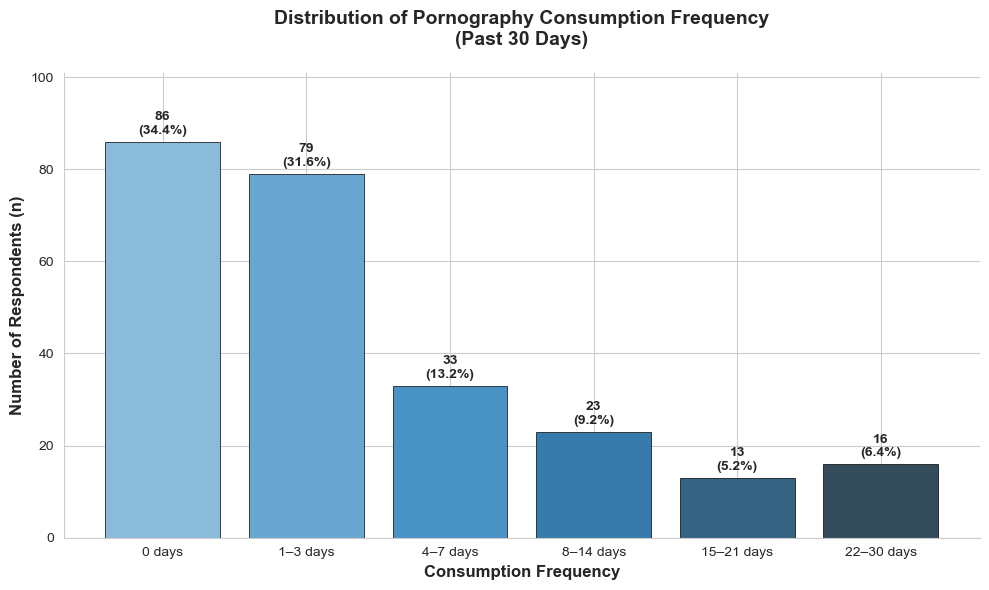

✅ Figure 4.1 saved as 'figure_4_1_porn_consumption.png'


In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ========================================
# DATA FOR FIGURE 4.1
# ========================================
categories = ['0 days', '1–3 days', '4–7 days', '8–14 days', '15–21 days', '22–30 days']
counts = [86, 79, 33, 23, 13, 16]
total_n = sum(counts)  # 250
percentages = [(c / total_n) * 100 for c in counts]

# ========================================
# CREATE THE BAR CHART
# ========================================
# Set a clean, professional style
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Create the bars with a professional blue color palette
colors = sns.color_palette("Blues_d", len(categories))
bars = ax.bar(categories, counts, color=colors, edgecolor='black', linewidth=0.5)

# ========================================
# ADD TITLES AND LABELS
# ========================================
ax.set_title('Distribution of Pornography Consumption Frequency\n(Past 30 Days)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Consumption Frequency', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Respondents (n)', fontsize=12, fontweight='bold')

# ========================================
# ADD DATA LABELS (Counts and Percentages)
# ========================================
for bar, count, pct in zip(bars, counts, percentages):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + 1,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Adjust y-axis limit to make room for the labels
ax.set_ylim(0, max(counts) + 15)

# Remove the top and right spines for a cleaner look
sns.despine()

# ========================================
# SAVE AND DISPLAY
# ========================================
plt.tight_layout()
plt.savefig('figure_4_1_porn_consumption.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure 4.1 saved as 'figure_4_1_porn_consumption.png'")

## Step 13 — Objective 1: Pornography consumption and productivity

Our hypothesis is:

H₀₁: There is no statistically significant relationship between pornography consumption and productivity among young adults.

H₁₁: There is a statistically significant relationship between pornography consumption and productivity among young adults.

In [38]:
print("Pornography frequency:")
print(df["porn_frequency"].describe())

print("\nProductivity:")
print(df["productivity"].describe())

Pornography frequency:
count    250.00000
mean       1.38400
std        1.48234
min        0.00000
25%        0.00000
50%        1.00000
75%        2.00000
max        5.00000
Name: porn_frequency, dtype: float64

Productivity:
count    250.000000
mean       6.108000
std        1.924357
min        1.000000
25%        5.000000
50%        6.000000
75%        7.000000
max       10.000000
Name: productivity, dtype: float64


In [39]:
objective1_df = df[
    ["porn_frequency", "productivity"]
].dropna()

print("N used for Objective 1:", len(objective1_df))

N used for Objective 1: 250


In [40]:
rho, p_value = stats.spearmanr(
    objective1_df["porn_frequency"],
    objective1_df["productivity"]
)

print("Spearman's rho:", round(rho, 3))
print("p-value:", round(p_value, 4))

Spearman's rho: -0.157
p-value: 0.013


In [41]:
summary_by_frequency = (
    df.groupby("porn_frequency", observed=True)["productivity"]
      .agg(
          N="count",
          Mean="mean",
          SD="std",
          Median="median"
      )
      .round(2)
)

summary_by_frequency

,N,Mean,SD,Median
porn_frequency,,,,
0,86,6.55,1.81,7.0
1,79,6.03,2.06,7.0
2,33,5.73,1.75,6.0
3,23,5.57,1.93,6.0
4,13,5.85,2.19,6.0
5,16,5.94,1.77,6.0


<Figure size 900x600 with 0 Axes>

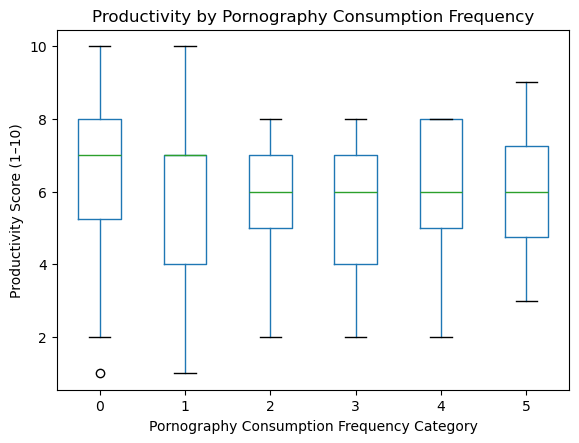

In [42]:
plt.figure(figsize=(9, 6))

df.boxplot(
    column="productivity",
    by="porn_frequency",
    grid=False
)

plt.title("Productivity by Pornography Consumption Frequency")
plt.suptitle("")
plt.xlabel("Pornography Consumption Frequency Category")
plt.ylabel("Productivity Score (1–10)")
plt.show()

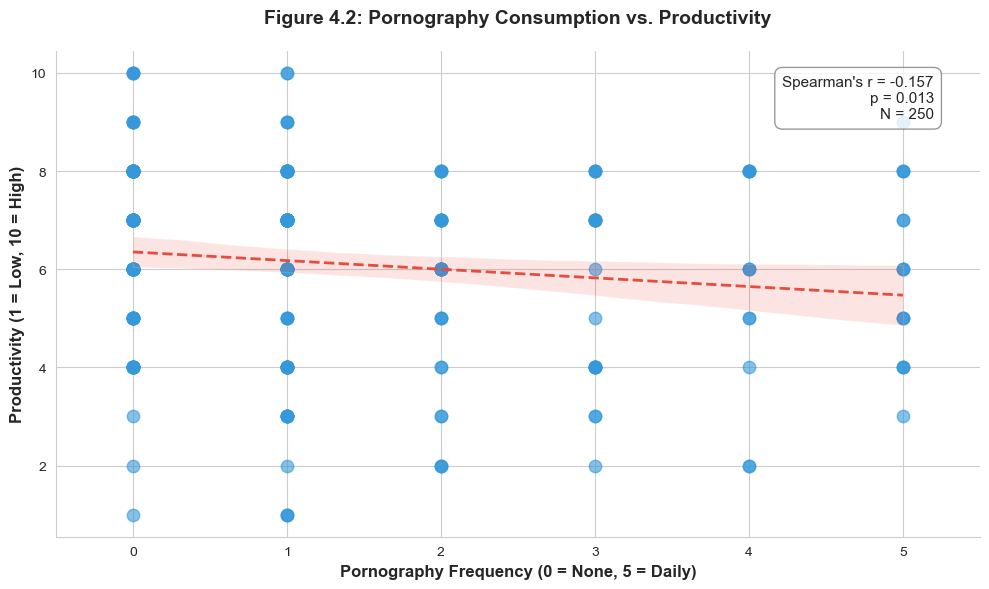

✅ Figure 4.2 saved as 'figure_4_2_scatter.png'


In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ========================================
# PREPARE DATA FOR FIGURE 4.2
# ========================================
# Drop missing values for these two variables
plot_data = df[['porn_frequency', 'productivity']].dropna()

# ========================================
# CREATE THE SCATTER PLOT
# ========================================
# Set a clean, academic style
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Create scatter plot with a regression (trend) line
sns.regplot(
    data=plot_data,
    x='porn_frequency',
    y='productivity',
    scatter_kws={'alpha': 0.6, 'color': '#3498db', 's': 80}, # Blue dots
    line_kws={'color': '#e74c3c', 'linewidth': 2, 'linestyle': '--'} # Red dashed trend line
)

# ========================================
# ADD TITLES AND LABELS
# ========================================
ax.set_title('Figure 4.2: Pornography Consumption vs. Productivity', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Pornography Frequency (0 = None, 5 = Daily)', fontsize=12, fontweight='bold')
ax.set_ylabel('Productivity (1 = Low, 10 = High)', fontsize=12, fontweight='bold')

# ========================================
# ADD STATISTICAL ANNOTATION
# ========================================
# Add the Spearman's rho and p-value directly onto the chart
stats_text = f"Spearman's r = -0.157\np = 0.013\nN = 250"
ax.text(
    0.95, 0.95, stats_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
)

# Set x-axis limits to start exactly at 0
ax.set_xlim(-0.5, 5.5)

# Remove the top and right spines for a cleaner look
sns.despine()

# ========================================
# SAVE AND DISPLAY
# ========================================
plt.tight_layout()
plt.savefig('figure_4_2_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure 4.2 saved as 'figure_4_2_scatter.png'")

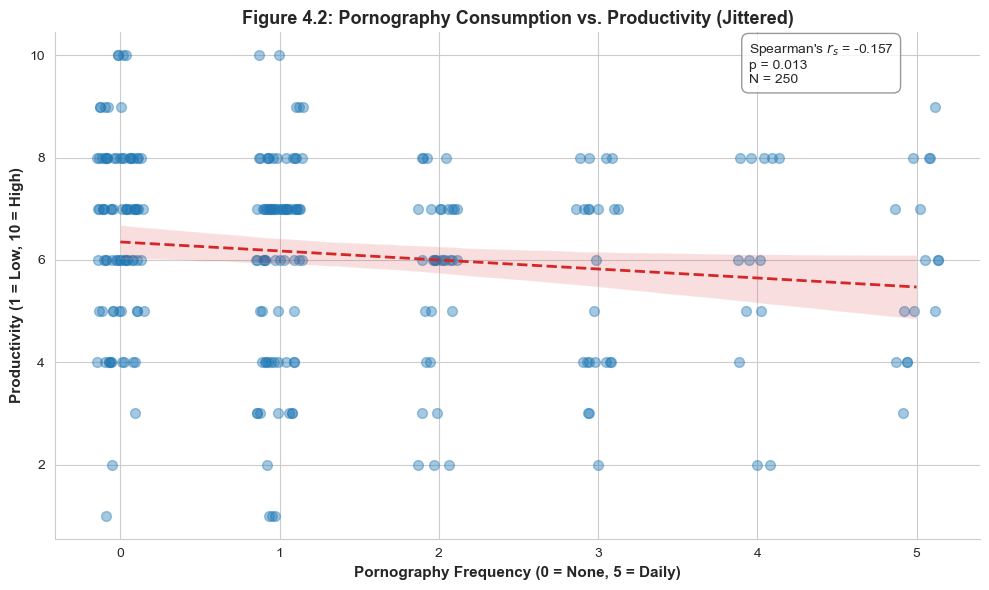

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# regplot with x_jitter spreads the points horizontally so density is visible
ax = sns.regplot(
    data=df, 
    x='porn_frequency', 
    y='productivity',
    x_jitter=0.15,          # Adds subtle horizontal spread
    scatter_kws={'alpha': 0.4, 'color': '#1f77b4', 's': 50}, # alpha shows overlapping points
    line_kws={'color': '#d62728', 'linestyle': '--', 'linewidth': 2}
)

# Fix character artifact using proper LaTeX symbol or r_s
plt.text(0.75, 0.90, "Spearman's $r_s$ = -0.157\np = 0.013\nN = 250", 
         transform=ax.transAxes, 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.title("Figure 4.2: Pornography Consumption vs. Productivity (Jittered)", fontsize=13, fontweight='bold')
plt.xlabel("Pornography Frequency (0 = None, 5 = Daily)", fontsize=11, fontweight='bold')
plt.ylabel("Productivity (1 = Low, 10 = High)", fontsize=11, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

### Objective 2 — Does self-control mediate the relationship?

Our proposed model is:

Pornography consumption → Self-control → Productivity

In [44]:
med_df = df[
    ["porn_frequency", "self_control", "productivity"]
].dropna()

print("N for mediation analysis:", len(med_df))

N for mediation analysis: 235


In [45]:
med_df.describe()

,porn_frequency,self_control,productivity
count,235.000000,235.000000,235.000000
mean,1.400000,3.091915,6.110638
std,1.491285,0.758132,1.955841
min,0.000000,1.200000,1.000000
25%,0.000000,2.600000,5.000000
50%,1.000000,3.000000,6.000000
75%,2.000000,3.600000,8.000000
max,5.000000,5.000000,10.000000


In [46]:
model_a = smf.ols(
    "self_control ~ porn_frequency",
    data=med_df
).fit()

print(model_a.summary())

                            OLS Regression Results                            
Dep. Variable:           self_control   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     20.74
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           8.47e-06
Time:                        23:51:34   Log-Likelihood:                -257.86
No. Observations:                 235   AIC:                             519.7
Df Residuals:                     233   BIC:                             526.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.2954      0.065     50.

In [47]:
model_b = smf.ols(
    "productivity ~ porn_frequency + self_control",
    data=med_df
).fit()

print(model_b.summary())

                            OLS Regression Results                            
Dep. Variable:           productivity   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     37.91
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           5.68e-15
Time:                        23:53:42   Log-Likelihood:                -457.37
No. Observations:                 235   AIC:                             920.7
Df Residuals:                     232   BIC:                             931.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.0555      0.528      3.

In [48]:
model_total = smf.ols(
    "productivity ~ porn_frequency",
    data=med_df
).fit()

print(model_total.summary())


                            OLS Regression Results                            
Dep. Variable:           productivity   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     3.362
Date:                Thu, 10 Sep 2026   Prob (F-statistic):             0.0680
Time:                        23:54:17   Log-Likelihood:                -488.91
No. Observations:                 235   AIC:                             981.8
Df Residuals:                     233   BIC:                             988.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          6.3296      0.174     36.

In [49]:
rng = np.random.default_rng(42)

n_boot = 5000
indirect_effects = np.empty(n_boot)

n = len(med_df)

for i in range(n_boot):
    sample_idx = rng.integers(0, n, n)
    sample = med_df.iloc[sample_idx]

    # Path a
    a_model = smf.ols(
        "self_control ~ porn_frequency",
        data=sample
    ).fit()

    # Path b
    b_model = smf.ols(
        "productivity ~ porn_frequency + self_control",
        data=sample
    ).fit()

    a = a_model.params["porn_frequency"]
    b = b_model.params["self_control"]

    indirect_effects[i] = a * b

indirect = np.mean(indirect_effects)

ci_lower = np.percentile(indirect_effects, 2.5)
ci_upper = np.percentile(indirect_effects, 97.5)

print("Indirect effect (a × b):", round(indirect, 4))
print("95% bootstrap CI:", (round(ci_lower, 4), round(ci_upper, 4)))

Indirect effect (a × b): -0.188
95% bootstrap CI: (np.float64(-0.2874), np.float64(-0.0981))


In [50]:
print("PATH A: Pornography → Self-control")
print(
    "Coefficient:",
    round(model_a.params["porn_frequency"], 4),
    "p-value:",
    round(model_a.pvalues["porn_frequency"], 4)
)

print("\nPATH B: Self-control → Productivity")
print(
    "Coefficient:",
    round(model_b.params["self_control"], 4),
    "p-value:",
    round(model_b.pvalues["self_control"], 4)
)

print("\nDIRECT EFFECT (c'):")
print(
    "Coefficient:",
    round(model_b.params["porn_frequency"], 4),
    "p-value:",
    round(model_b.pvalues["porn_frequency"], 4)
)

print("\nTOTAL EFFECT (c):")
print(
    "Coefficient:",
    round(model_total.params["porn_frequency"], 4),
    "p-value:",
    round(model_total.pvalues["porn_frequency"], 4)
)

print("\nINDIRECT EFFECT (a × b):")
print("Effect:", round(indirect, 4))
print("95% CI:", (round(ci_lower, 4), round(ci_upper, 4)))

PATH A: Pornography → Self-control
Coefficient: -0.1453 p-value: 0.0

PATH B: Self-control → Productivity
Coefficient: 1.297 p-value: 0.0

DIRECT EFFECT (c'):
Coefficient: 0.0321 p-value: 0.6811

TOTAL EFFECT (c):
Coefficient: -0.1564 p-value: 0.068

INDIRECT EFFECT (a × b):
Effect: -0.188
95% CI: (np.float64(-0.2874), np.float64(-0.0981))


In [51]:
print("Path A R²:", round(model_a.rsquared, 3))
print("Path B/Direct Model R²:", round(model_b.rsquared, 3))
print("Total Effect Model R²:", round(model_total.rsquared, 3))

Path A R²: 0.082
Path B/Direct Model R²: 0.246
Total Effect Model R²: 0.014


In [52]:
mediation_summary = pd.DataFrame({
    "Effect": [
        "Path a: Pornography → Self-control",
        "Path b: Self-control → Productivity",
        "Total effect (c)",
        "Direct effect (c')",
        "Indirect effect (a × b)"
    ],
    "Coefficient": [
        model_a.params["porn_frequency"],
        model_b.params["self_control"],
        model_total.params["porn_frequency"],
        model_b.params["porn_frequency"],
        indirect
    ],
    "p_value": [
        model_a.pvalues["porn_frequency"],
        model_b.pvalues["self_control"],
        model_total.pvalues["porn_frequency"],
        model_b.pvalues["porn_frequency"],
        np.nan
    ]
})

mediation_summary.round(4)

,Effect,Coefficient,p_value
0,Path a: Pornography → Self-control,-0.1453,0.0000
1,Path b: Self-control → Productivity,1.2970,0.0000
2,Total effect (c),-0.1564,0.0680
3,Direct effect (c'),0.0321,0.6811
4,Indirect effect (a × b),-0.1880,NaN


In [53]:
print("Indirect effect 95% Bootstrap CI:",
      round(ci_lower, 4),
      "to",
      round(ci_upper, 4))

print("\nR²:")
print("Path A:", round(model_a.rsquared, 4))
print("Direct model:", round(model_b.rsquared, 4))
print("Total effect model:", round(model_total.rsquared, 4))

Indirect effect 95% Bootstrap CI: -0.2874 to -0.0981

R²:
Path A: 0.0817
Direct model: 0.2463
Total effect model: 0.0142


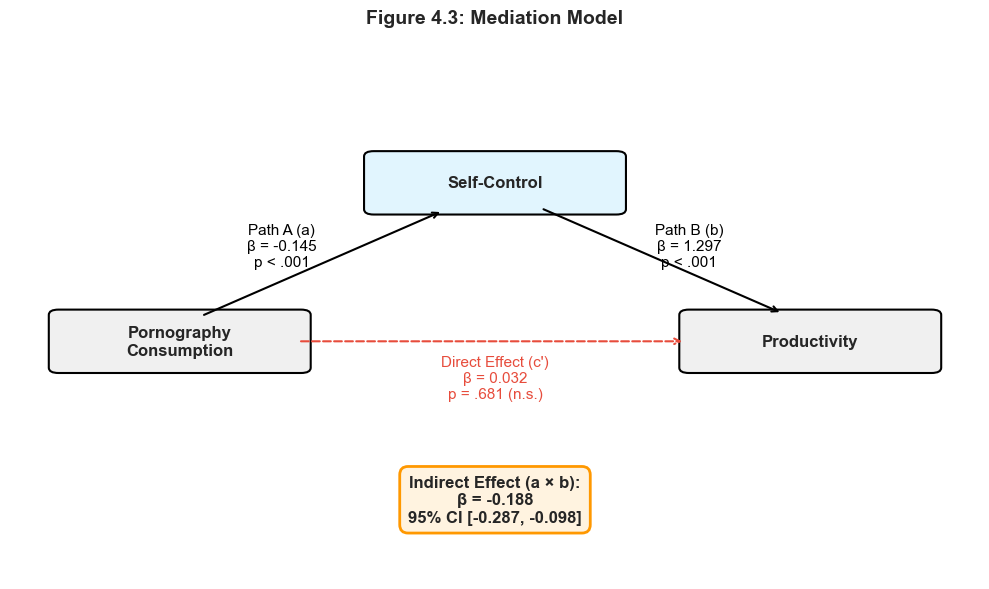

✅ Figure 4.3 saved as 'figure_4_3_mediation.png'


In [130]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ========================================
# SET UP THE FIGURE
# ========================================
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')  # Hide the axes

# ========================================
# DRAW THE BOXES (Nodes)
# ========================================

# 1. Pornography Consumption (Left)
ax.add_patch(patches.FancyBboxPatch((0.5, 4.0), 2.5, 1.0, boxstyle="round,pad=0.1", 
                                    edgecolor='black', facecolor='#f0f0f0', linewidth=1.5))
ax.text(1.75, 4.5, 'Pornography\nConsumption', ha='center', va='center', fontsize=12, fontweight='bold')

# 2. Self-Control (Middle)
ax.add_patch(patches.FancyBboxPatch((3.75, 7.0), 2.5, 1.0, boxstyle="round,pad=0.1", 
                                    edgecolor='black', facecolor='#e1f5fe', linewidth=1.5))
ax.text(5.0, 7.5, 'Self-Control', ha='center', va='center', fontsize=12, fontweight='bold')

# 3. Productivity (Right)
ax.add_patch(patches.FancyBboxPatch((7.0, 4.0), 2.5, 1.0, boxstyle="round,pad=0.1", 
                                    edgecolor='black', facecolor='#f0f0f0', linewidth=1.5))
ax.text(8.25, 4.5, 'Productivity', ha='center', va='center', fontsize=12, fontweight='bold')

# ========================================
# DRAW THE ARROWS (Paths)
# ========================================

# Path A: Pornography -> Self-Control
ax.annotate('', xy=(4.5, 7.0), xytext=(2.0, 5.0),
            arrowprops=dict(arrowstyle='->', color='black', linewidth=1.5, shrinkA=0, shrinkB=5))
ax.text(2.8, 6.3, 'Path A (a)\nβ = -0.145\np < .001', ha='center', va='center', fontsize=11, color='black')

# Path B: Self-Control -> Productivity
ax.annotate('', xy=(8.0, 5.0), xytext=(5.5, 7.0),
            arrowprops=dict(arrowstyle='->', color='black', linewidth=1.5, shrinkA=0, shrinkB=5))
ax.text(7.0, 6.3, 'Path B (b)\nβ = 1.297\np < .001', ha='center', va='center', fontsize=11, color='black')

# Direct Effect (c'): Pornography -> Productivity
ax.annotate('', xy=(7.0, 4.5), xytext=(3.0, 4.5),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', linewidth=1.5, linestyle='--', shrinkA=0, shrinkB=5))
ax.text(5.0, 3.8, "Direct Effect (c')\nβ = 0.032\np = .681 (n.s.)", ha='center', va='center', fontsize=11, color='#e74c3c')

# ========================================
# ADD THE INDIRECT EFFECT ANNOTATION
# ========================================
# Indirect Effect text box
ax.text(5.0, 1.5, "Indirect Effect (a × b):\nβ = -0.188\n95% CI [-0.287, -0.098]", 
        ha='center', va='center', fontsize=12, fontweight='bold', 
        bbox=dict(boxstyle="round,pad=0.5", facecolor='#fff3e0', edgecolor='#ff9800', linewidth=2))

# ========================================
# SAVE AND DISPLAY
# ========================================
plt.title('Figure 4.3: Mediation Model', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figure_4_3_mediation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure 4.3 saved as 'figure_4_3_mediation.png'")

### Objective 3

To investigate whether age of first exposure predicts current consumption patterns, self-control, and productivity, and to identify whether early exposure has a lasting impact into adulthood.

In [54]:
first_exposure_col = (
    "Q5. At what age did you first intentionally view pornography?"
)

exposure_order = [
    "<10 years",
    "11-13 years",
    "14-17 years",
    "18 -21 years",
    "22+"
]

df["first_exposure"] = pd.Categorical(
    df[first_exposure_col],
    categories=exposure_order,
    ordered=True
)

In [55]:
print(df["first_exposure"].value_counts(dropna=False))

first_exposure
11-13 years     86
14-17 years     74
18 -21 years    40
22+             22
<10 years       14
NaN             14
Name: count, dtype: int64


In [56]:
exposure_map = {
    "<10 years": 1,
    "11-13 years": 2,
    "14-17 years": 3,
    "18 -21 years": 4,
    "22+": 5
}

df["first_exposure_ord"] = df["first_exposure"].map(exposure_map)

In [57]:
print(df["first_exposure_ord"].value_counts(dropna=False).sort_index())

first_exposure_ord
1      14
2      86
3      74
4      40
5      22
NaN    14
Name: count, dtype: int64


In [58]:
objective3_df = df[
    [
        "first_exposure_ord",
        "porn_frequency",
        "self_control",
        "productivity"
    ]
].dropna()

print("N for Objective 3:", len(objective3_df))

N for Objective 3: 223


In [59]:
rho_consumption, p_consumption = stats.spearmanr(
    objective3_df["first_exposure_ord"],
    objective3_df["porn_frequency"]
)

rho_selfcontrol, p_selfcontrol = stats.spearmanr(
    objective3_df["first_exposure_ord"],
    objective3_df["self_control"]
)

rho_productivity, p_productivity = stats.spearmanr(
    objective3_df["first_exposure_ord"],
    objective3_df["productivity"]
)

print("First exposure ↔ Current consumption")
print("rho =", round(rho_consumption, 3), "p =", round(p_consumption, 4))

print("\nFirst exposure ↔ Self-control")
print("rho =", round(rho_selfcontrol, 3), "p =", round(p_selfcontrol, 4))

print("\nFirst exposure ↔ Productivity")
print("rho =", round(rho_productivity, 3), "p =", round(p_productivity, 4))

First exposure ↔ Current consumption
rho = -0.121 p = 0.0704

First exposure ↔ Self-control
rho = 0.217 p = 0.0011

First exposure ↔ Productivity
rho = 0.216 p = 0.0012


In [62]:
model_3a = smf.ols(
    "porn_frequency ~ first_exposure_ord",
    data=objective3_df
).fit()

model_3b = smf.ols(
    "self_control ~ first_exposure_ord",
    data=objective3_df
).fit()

model_3c = smf.ols(
    "productivity ~ first_exposure_ord",
    data=objective3_df
).fit()

print("MODEL 1: First exposure → Current consumption")
print(model_3a.summary())

print("\nMODEL 2: First exposure → Self-control")
print(model_3b.summary())

print("\nMODEL 3: First exposure → Productivity")
print(model_3c.summary())

MODEL 1: First exposure → Current consumption
                            OLS Regression Results                            
Dep. Variable:         porn_frequency   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.192
Date:                Fri, 11 Sep 2026   Prob (F-statistic):              0.315
Time:                        00:13:11   Log-Likelihood:                -403.06
No. Observations:                 223   AIC:                             816.1
Df Residuals:                     218   BIC:                             833.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [63]:
# ============================================================
# OBJECTIVE 3 — AGE OF FIRST EXPOSURE
# Self-contained preparation + regression analysis
# ============================================================

# 1. Identify the original column
first_exposure_col = (
    "Q5. At what age did you first intentionally view pornography?"
)

# 2. Clean the response text
df["first_exposure_clean"] = (
    df[first_exposure_col]
    .astype("string")
    .str.strip()
    .str.replace("–", "-", regex=False)
    .str.replace("â€“", "-", regex=False)
)

# 3. Convert ordered categories to numerical scores
exposure_map = {
    "<10 years": 1,
    "11-13 years": 2,
    "14-17 years": 3,
    "18 -21 years": 4,
    "18-21 years": 4,
    "22+": 5
}

df["first_exposure_ord"] = df["first_exposure_clean"].map(exposure_map)

# 4. Check that the variable was actually created
print("Column created:", "first_exposure_ord" in df.columns)
print("\nExposure categories:")
print(df["first_exposure_clean"].value_counts(dropna=False))

print("\nExposure coding:")
print(df["first_exposure_ord"].value_counts(dropna=False).sort_index())

# 5. Make sure our other required variables exist
required_vars = [
    "porn_frequency",
    "self_control",
    "productivity",
    "first_exposure_ord"
]

missing_vars = [v for v in required_vars if v not in df.columns]

if missing_vars:
    raise ValueError(
        f"These required variables are missing from df: {missing_vars}"
    )

# 6. Create Objective 3 dataset
objective3_df = df[
    [
        "first_exposure_ord",
        "porn_frequency",
        "self_control",
        "productivity"
    ]
].dropna()

print("\nN for Objective 3:", len(objective3_df))

# 7. Run regression models
model_3a = smf.ols(
    "porn_frequency ~ first_exposure_ord",
    data=objective3_df
).fit()

model_3b = smf.ols(
    "self_control ~ first_exposure_ord",
    data=objective3_df
).fit()

model_3c = smf.ols(
    "productivity ~ first_exposure_ord",
    data=objective3_df
).fit()

# 8. Create compact results table
results_3 = pd.DataFrame({
    "Outcome": [
        "Current pornography consumption",
        "Self-control",
        "Productivity"
    ],
    "Coefficient": [
        model_3a.params["first_exposure_ord"],
        model_3b.params["first_exposure_ord"],
        model_3c.params["first_exposure_ord"]
    ],
    "SE": [
        model_3a.bse["first_exposure_ord"],
        model_3b.bse["first_exposure_ord"],
        model_3c.bse["first_exposure_ord"]
    ],
    "p_value": [
        model_3a.pvalues["first_exposure_ord"],
        model_3b.pvalues["first_exposure_ord"],
        model_3c.pvalues["first_exposure_ord"]
    ],
    "R_squared": [
        model_3a.rsquared,
        model_3b.rsquared,
        model_3c.rsquared
    ]
})

print("\nObjective 3 Regression Results:")
display(results_3.round(4))

Column created: True

Exposure categories:
first_exposure_clean
11-13 years     86
14-17 years     74
18 -21 years    40
22+             22
<10 years       14
Never           13
<NA>             1
Name: count, dtype: Int64

Exposure coding:
first_exposure_ord
1.0    14
2.0    86
3.0    74
4.0    40
5.0    22
NaN    14
Name: count, dtype: int64

N for Objective 3: 223

Objective 3 Regression Results:


,Outcome,Coefficient,SE,p_value,R_squared
0,Current pornography consumption,-0.1916,0.0939,0.0426,0.0185
1,Self-control,0.1494,0.0462,0.0014,0.0451
2,Productivity,0.4193,0.1204,0.0006,0.0521


In [79]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Calculate exact group means for Self-Control by Exposure Category
mean_sc_by_age = (
    objective3_df.groupby("first_exposure_ord")["self_control"]
    .agg(["count", "mean", "std"])
    .reset_index()
)
print("--- MEAN SELF-CONTROL BY AGE BRACKET ---")
print(mean_sc_by_age)

# 2. Pairwise Tukey HSD Test (Pinpoints exactly WHICH categories differ from WHICH)
tukey = pairwise_tukeyhsd(
    endog=objective3_df["self_control"].dropna(),
    groups=objective3_df.dropna(subset=["self_control"])[
        "first_exposure_ord"
    ],
    alpha=0.05,
)
print("\n--- PAIRWISE CATEGORY COMPARISONS ---")
print(tukey)


--- MEAN SELF-CONTROL BY AGE BRACKET ---
   first_exposure_ord  count      mean       std
0                 1.0     13  2.830769  0.756510
1                 2.0     83  2.944578  0.745924
2                 3.0     71  2.997183  0.722292
3                 4.0     35  3.474286  0.716340
4                 5.0     21  3.228571  0.645866

--- PAIRWISE CATEGORY COMPARISONS ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   1.0    2.0   0.1138 0.9847 -0.4816 0.7092  False
   1.0    3.0   0.1664 0.9416 -0.4358 0.7686  False
   1.0    4.0   0.6435 0.0528 -0.0048 1.2919  False
   1.0    5.0   0.3978  0.529 -0.3067 1.1023  False
   2.0    3.0   0.0526 0.9916 -0.2701 0.3753  False
   2.0    4.0   0.5297 0.0033  0.1274  0.932   True
   2.0    5.0    0.284 0.4976 -0.2036 0.7716  False
   3.0    4.0   0.4771 0.0143  0.0648 0.8894   True
   3.0    5.0   0.2314 0.7016 -0.2645 0.7272  False
  

In [139]:
print(df.columns.tolist())

['Timestamp', 'Q1. In the last 7 days, how satisfied were you with your overall work/study output?', 'Q2. In the past 7 days, how often have you procrastinated on important tasks?', 'Q3. On a scale of 1â€“10, how stressed have you felt over the last 7 days?', 'Q4. In the past 7 days, approximately how many total hours did you spend viewing pornography during time that you should have been working or studying?', 'Q5. How would you rate your overall productivity over the last 7 days on a scale of 1â€“10?', 'Please rate how much you agree with the following statements [I have a hard time breaking my bad habits]', 'Please rate how much you agree with the following statements [I am good at resisting temptations.]', 'Please rate how much you agree with the following statements [I often do things that feel good in the moment, but regret them]', 'Please rate how much you agree with the following statements [I act without thinking through all the alternatives]', 'Please rate how much you agree 

In [140]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ========================================
# STEP 1: Create the ordinal exposure column inside df
# ========================================

exposure_col = 'Q5. At what age did you first intentionally view pornography?'

exposure_map = {
    '<10 years': 1,
    '11-13 years': 2,
    '14-17 years': 3,
    '18 -21 years': 4,
    '22+': 5
}

df['first_exposure_ord'] = df[exposure_col].map(exposure_map)

print("✅ Column created!")
print(df['first_exposure_ord'].value_counts().sort_index())
print(f"\nN with valid exposure data: {df['first_exposure_ord'].notna().sum()}")

# ========================================
# STEP 2: Run the One-Way ANOVA for Self-Control
# ========================================

anova_data = df[['first_exposure_ord', 'self_control']].dropna()

model = ols('self_control ~ C(first_exposure_ord)', data=anova_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n" + "="*60)
print("ONE-WAY ANOVA: Self-Control by Age of First Exposure")
print("="*60)
print(anova_table)
print("="*60)

✅ Column created!
first_exposure_ord
1.0    14
2.0    86
3.0    74
4.0    40
5.0    22
Name: count, dtype: int64

N with valid exposure data: 236

ONE-WAY ANOVA: Self-Control by Age of First Exposure
                           sum_sq     df         F  PR(>F)
C(first_exposure_ord)    8.668231    4.0  4.115076  0.0031
Residual               114.801903  218.0       NaN     NaN


In [ ]:
import pandas as pd
import statsmodels.api as sm✅ Column created!
first_exposure_ord
1.0    14
2.0    86
3.0    74
4.0    40
5.0    22
Name: count, dtype: int64

N with valid exposure data: 236

============================================================
ONE-WAY ANOVA: Self-Control by Age of First Exposure
============================================================
                           sum_sq     df         F  PR(>F)
C(first_exposure_ord)    8.668231    4.0  4.115076  0.0031
Residual               114.801903  218.0       NaN     NaN
============================================================
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Filter out non-exposed/missing cases (N = 223)
exp_df = objective3_df.dropna(subset=["first_exposure_ord", "productivity"]).copy()

# 2. Group Means, Sample Sizes, and Standard Deviations
productivity_by_age = (
    exp_df.groupby("first_exposure_ord")["productivity"]
    .agg(Count="count", Mean="mean", Std="std")
    .reset_index()
)

print("=== 1. MEAN PRODUCTIVITY BY EXPOSURE AGE CATEGORY ===")
print(productivity_by_age.to_string(index=False))
print("\n" + "=" * 50 + "\n")

# 3. One-Way ANOVA
model = ols("productivity ~ C(first_exposure_ord)", data=exp_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== 2. ONE-WAY ANOVA RESULTS ===")
print(anova_table)
print("\n" + "=" * 50 + "\n")

# 4. Pairwise Tukey HSD Post-Hoc Test
tukey_prod = pairwise_tukeyhsd(
    endog=exp_df["productivity"],
    groups=exp_df["first_exposure_ord"],
    alpha=0.05,
)

print("=== 3. PAIRWISE CATEGORY COMPARISONS (TUKEY HSD) ===")
print(tukey_prod)

=== 1. MEAN PRODUCTIVITY BY EXPOSURE AGE CATEGORY ===
 first_exposure_ord  Count     Mean      Std
                1.0     13 4.923077 1.891276
                2.0     83 5.698795 2.099564
                3.0     71 6.225352 1.814207
                4.0     35 6.514286 1.597267
                5.0     21 6.761905 1.921061


=== 2. ONE-WAY ANOVA RESULTS ===
                           sum_sq     df         F    PR(>F)
C(first_exposure_ord)   47.117696    4.0  3.228701  0.013383
Residual               795.339704  218.0       NaN       NaN


=== 3. PAIRWISE CATEGORY COMPARISONS (TUKEY HSD) ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   1.0    2.0   0.7757 0.6529 -0.7915 2.3429  False
   1.0    3.0   1.3023 0.1621 -0.2828 2.8873  False
   1.0    4.0   1.5912 0.0806 -0.1153 3.2977  False
   1.0    5.0   1.8388 0.0531 -0.0154  3.693  False
   2.0    3.0   0.5266 0.4328 -0.3228 1

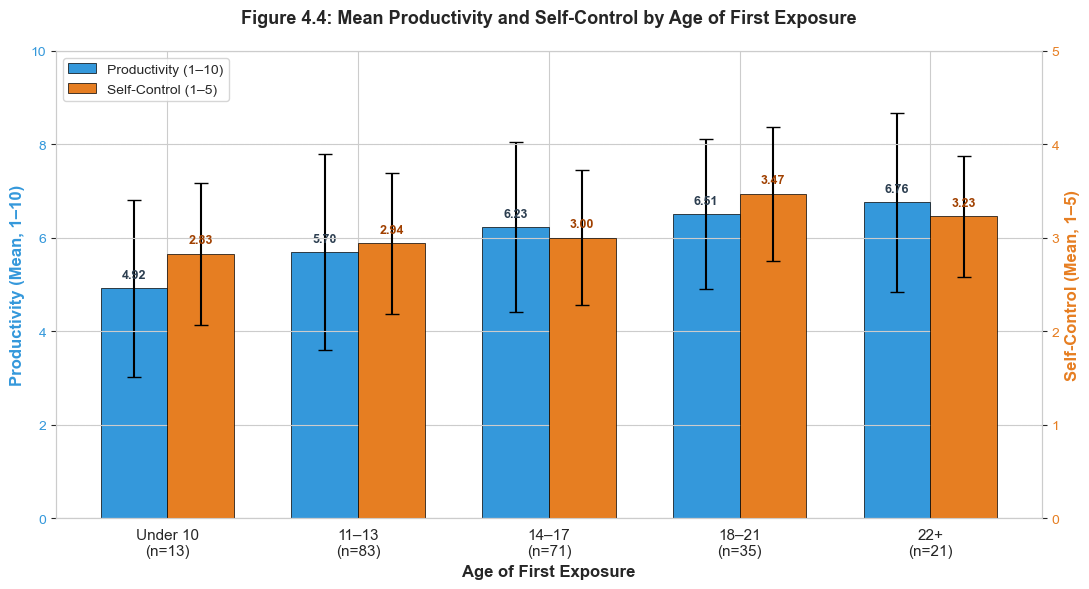

✅ Figure 4.4 saved as 'figure_4_4_exposure.png'


In [141]:
import matplotlib.pyplot as plt
import numpy as np

# ========================================
# DATA FOR FIGURE 4.4
# ========================================
exposure_groups = ['Under 10\n(n=13)', '11–13\n(n=83)', '14–17\n(n=71)', '18–21\n(n=35)', '22+\n(n=21)']

# Means
self_control_mean = [2.83, 2.94, 3.00, 3.47, 3.23]
productivity_mean = [4.92, 5.70, 6.23, 6.51, 6.76]

# Standard Deviations
self_control_sd = [0.76, 0.75, 0.72, 0.72, 0.65]
productivity_sd = [1.89, 2.10, 1.81, 1.60, 1.92]

# ========================================
# CREATE THE DUAL-AXIS CHART
# ========================================
fig, ax1 = plt.subplots(figsize=(11, 6))

x = np.arange(len(exposure_groups))
width = 0.35

# ---- Productivity (Left Y-Axis) ----
bars1 = ax1.bar(x - width/2, productivity_mean, width, 
                yerr=productivity_sd, capsize=5,
                color='#3498db', edgecolor='black', linewidth=0.5,
                label='Productivity (1–10)')
ax1.set_xlabel('Age of First Exposure', fontsize=12, fontweight='bold')
ax1.set_ylabel('Productivity (Mean, 1–10)', fontsize=12, fontweight='bold', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.set_ylim(0, 10)

# ---- Self-Control (Right Y-Axis) ----
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, self_control_mean, width,
                yerr=self_control_sd, capsize=5,
                color='#e67e22', edgecolor='black', linewidth=0.5,
                label='Self-Control (1–5)')
ax2.set_ylabel('Self-Control (Mean, 1–5)', fontsize=12, fontweight='bold', color='#e67e22')
ax2.tick_params(axis='y', labelcolor='#e67e22')
ax2.set_ylim(0, 5)

# ========================================
# ADD DATA LABELS
# ========================================
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.15,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2c3e50')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.08,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#a04000')

# ========================================
# TITLES AND FORMATTING
# ========================================
ax1.set_xticks(x)
ax1.set_xticklabels(exposure_groups, fontsize=11)
plt.title('Figure 4.4: Mean Productivity and Self-Control by Age of First Exposure',
          fontsize=13, fontweight='bold', pad=20)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Clean grid
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

plt.tight_layout()
plt.savefig('figure_4_4_exposure.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure 4.4 saved as 'figure_4_4_exposure.png'")

### Final Objective 4

To compare pornography consumption, self-control, and productivity between male and female young adults.

In [64]:
# ============================================================
# OBJECTIVE 5 — GENDER COMPARISONS
# COMPLETE SETUP
# ============================================================

# Original gender column
gender_col = "Gender"

# Create cleaned gender variable
df["gender_clean"] = (
    df[gender_col]
    .astype("string")
    .str.strip()
    .str.title()
)

# Check the groups
print("Gender groups:")
print(df["gender_clean"].value_counts(dropna=False))

# Create the analysis dataset
gender_df = df[
    [
        "gender_clean",
        "porn_frequency",
        "self_control",
        "productivity"
    ]
].dropna(subset=["gender_clean"])

print("\nNumber of respondents by gender:")
print(gender_df["gender_clean"].value_counts())

print("\nMissing outcome values:")
print(
    gender_df[
        ["porn_frequency", "self_control", "productivity"]
    ].isna().sum()
)

Gender groups:
gender_clean
Female               136
Male                 113
Prefer Not To Say      1
Name: count, dtype: Int64

Number of respondents by gender:
gender_clean
Female               136
Male                 113
Prefer Not To Say      1
Name: count, dtype: Int64

Missing outcome values:
porn_frequency     0
self_control      15
productivity       0
dtype: int64


In [65]:
# Descriptive statistics by gender

gender_descriptives = (
    gender_df
    .groupby("gender_clean")[
        ["porn_frequency", "self_control", "productivity"]
    ]
    .agg(["count", "mean", "std", "median"])
    .round(3)
)

gender_descriptives

porn_frequency                      self_control         \
                           count   mean    std median        count   mean   
gender_clean                                                                
Female                       136  0.846  0.995    1.0          127  3.118   
Male                         113  2.044  1.698    2.0          107  3.049   
Prefer Not To Say              1  0.000    NaN    0.0            1  4.400   

                                productivity                       
                     std median        count   mean    std median  
gender_clean                                                       
Female             0.746    3.2          136  5.941  1.908    6.0  
Male               0.767    3.0          113  6.283  1.925    7.0  
Prefer Not To Say    NaN    4.4            1  9.000    NaN    9.0

In [144]:

# ------------------------------------------------------------
# Gender comparison: Pornography frequency
# ------------------------------------------------------------

female_porn = gender_df.loc[
    gender_df["gender_clean"] == "Female",
    "porn_frequency"
]

male_porn = gender_df.loc[
    gender_df["gender_clean"] == "Male",
    "porn_frequency"
]

u_porn, p_porn = stats.mannwhitneyu(
    female_porn,
    male_porn,
    alternative="two-sided"
)

print("Mann–Whitney U:", round(u_porn, 3))
print("p-value:", round(p_porn, 5))

Mann–Whitney U: 4512.5
p-value: 0.0


In [67]:
# Rank-biserial correlation

n_female = len(female_porn)
n_male = len(male_porn)

rank_biserial = 1 - (2 * u_porn) / (n_female * n_male)

print("Rank-biserial correlation:", round(rank_biserial, 3))

Rank-biserial correlation: 0.413


In [146]:
female_sc = gender_df.loc[
    gender_df["gender_clean"] == "Female", "self_control"
].dropna()

male_sc = gender_df.loc[
    gender_df["gender_clean"] == "Male", "self_control"
].dropna()

t_sc, p_sc = stats.ttest_ind(female_sc, male_sc, equal_var=False)

print("Welch's t:", round(t_sc, 3))
print("p-value:", round(p_sc, 5))

Welch's t: 0.699
p-value: 0.48511


In [71]:
import numpy as np


def cohens_d(x, y):
    # Drop missing values automatically
    x = x.dropna().values
    y = y.dropna().values

    n1, n2 = len(x), len(y)
    s1, s2 = np.var(x, ddof=1), np.var(y, ddof=1)

    # Calculate pooled standard deviation
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))

    # Cohen's d formula
    return (np.mean(x) - np.mean(y)) / s_pooled


# Calculate and print Cohen's d
d_sc = cohens_d(female_sc, male_sc)

print("Cohen's d:", round(d_sc, 3))

Cohen's d: 0.092


In [72]:
female_prod = gender_df.loc[
    gender_df["gender_clean"] == "Female",
    "productivity"
]

male_prod = gender_df.loc[
    gender_df["gender_clean"] == "Male",
    "productivity"
]

t_prod, p_prod = stats.ttest_ind(
    female_prod,
    male_prod,
    equal_var=False
)

print("Welch's t:", round(t_prod, 3))
print("p-value:", round(p_prod, 5))

Welch's t: -1.401
p-value: 0.16239


In [73]:
d_prod = cohens_d(female_prod, male_prod)

print("Cohen's d:", round(d_prod, 3))

Cohen's d: -0.179


In [74]:
# ============================================================
# EFFECT SIZES FOR OBJECTIVE 4
# ============================================================

def cohens_d(group1, group2):
    """Calculate Cohen's d using pooled standard deviation."""
    
    n1 = len(group1)
    n2 = len(group2)

    mean1 = group1.mean()
    mean2 = group2.mean()

    var1 = group1.var(ddof=1)
    var2 = group2.var(ddof=1)

    pooled_sd = np.sqrt(
        ((n1 - 1) * var1 + (n2 - 1) * var2)
        / (n1 + n2 - 2)
    )

    return (mean1 - mean2) / pooled_sd


# Self-control
d_sc = cohens_d(female_sc, male_sc)

# Productivity
d_prod = cohens_d(female_prod, male_prod)

print("Cohen's d — Self-control:", round(d_sc, 3))
print("Cohen's d — Productivity:", round(d_prod, 3))

Cohen's d — Self-control: 0.092
Cohen's d — Productivity: -0.179


In [75]:
objective5_results = pd.DataFrame({
    "Outcome": [
        "Pornography frequency",
        "Self-control",
        "Productivity"
    ],
    "Female_Mean": [
        female_porn.mean(),
        female_sc.mean(),
        female_prod.mean()
    ],
    "Male_Mean": [
        male_porn.mean(),
        male_sc.mean(),
        male_prod.mean()
    ],
    "Test": [
        "Mann-Whitney U",
        "Welch t-test",
        "Welch t-test"
    ],
    "Statistic": [
        u_porn,
        t_sc,
        t_prod
    ],
    "p_value": [
        p_porn,
        p_sc,
        p_prod
    ],
    "Effect_Size": [
        rank_biserial,
        d_sc,
        d_prod
    ]
})

objective5_results.round(4)

,Outcome,Female_Mean,Male_Mean,Test,Statistic,p_value,Effect_Size
0,Pornography frequency,0.8456,2.0442,Mann-Whitney U,4512.5000,0.0000,0.4127
1,Self-control,3.1181,3.0486,Welch t-test,0.6993,0.4851,0.0920
2,Productivity,5.9412,6.2832,Welch t-test,-1.4014,0.1624,-0.1785


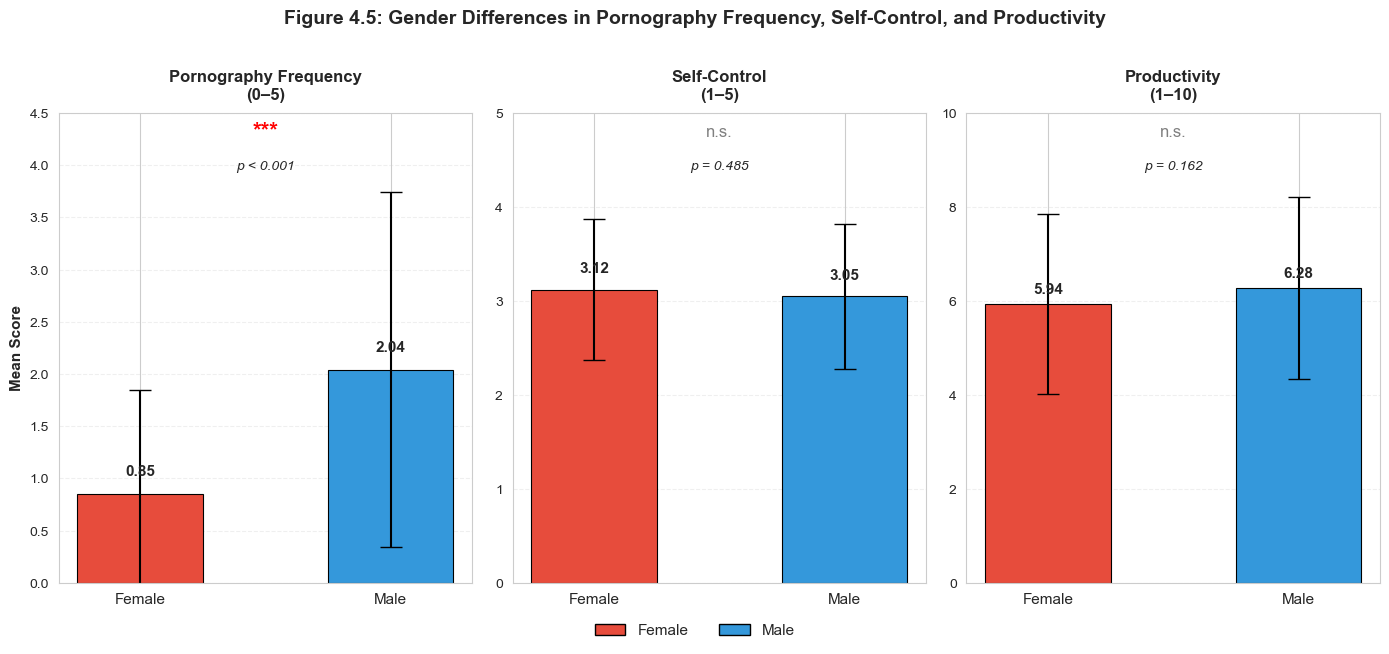

✅ Figure 4.5 saved as 'figure_4_5_gender.png'


In [142]:
import matplotlib.pyplot as plt
import numpy as np

# ========================================
# DATA FOR FIGURE 4.5
# ========================================
categories = ['Pornography Frequency\n(0–5)', 'Self-Control\n(1–5)', 'Productivity\n(1–10)']

# Means (Female, Male)
female_means = [0.85, 3.12, 5.94]
male_means = [2.04, 3.05, 6.28]

# Standard Deviations (Female, Male)
female_sd = [1.00, 0.75, 1.91]
male_sd = [1.70, 0.77, 1.93]

# P-values for significance annotation
p_values = [0.000, 0.485, 0.162]

# ========================================
# CREATE THE THREE-PANEL FIGURE
# ========================================
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

colors_female = '#e74c3c'  # Red
colors_male = '#3498db'    # Blue
x = np.arange(2)  # Two bars per panel (Female, Male)
width = 0.5

for i, ax in enumerate(axes):
    # Extract data for this variable
    means = [female_means[i], male_means[i]]
    sds = [female_sd[i], male_sd[i]]
    
    # Create bars
    bars = ax.bar(x, means, width, yerr=sds, capsize=8,
                  color=[colors_female, colors_male],
                  edgecolor='black', linewidth=0.8)
    
    # Add data labels above bars
    for bar, mean in zip(bars, means):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.15,
                f'{mean:.2f}', ha='center', va='bottom', 
                fontsize=11, fontweight='bold')
    
    # Titles and labels
    ax.set_title(categories[i], fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(['Female', 'Male'], fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Set y-limit based on variable scale
    if i == 0:
        ax.set_ylim(0, 4.5)
        ax.set_ylabel('Mean Score', fontsize=11, fontweight='bold')
    elif i == 1:
        ax.set_ylim(0, 5)
    else:
        ax.set_ylim(0, 10)
    
    # Add significance annotation
    if p_values[i] < 0.001:
        ax.text(0.5, 0.95, '***', transform=ax.transAxes, 
                ha='center', fontsize=16, fontweight='bold', color='red')
        ax.text(0.5, 0.88, 'p < 0.001', transform=ax.transAxes, 
                ha='center', fontsize=10, style='italic')
    elif p_values[i] < 0.05:
        ax.text(0.5, 0.95, '*', transform=ax.transAxes, 
                ha='center', fontsize=16, fontweight='bold', color='red')
        ax.text(0.5, 0.88, f'p = {p_values[i]:.3f}', transform=ax.transAxes, 
                ha='center', fontsize=10, style='italic')
    else:
        ax.text(0.5, 0.95, 'n.s.', transform=ax.transAxes, 
                ha='center', fontsize=12, color='gray')
        ax.text(0.5, 0.88, f'p = {p_values[i]:.3f}', transform=ax.transAxes, 
                ha='center', fontsize=10, style='italic')

# ========================================
# GLOBAL TITLE AND LAYOUT
# ========================================
fig.suptitle('Figure 4.5: Gender Differences in Pornography Frequency, Self-Control, and Productivity',
             fontsize=14, fontweight='bold', y=1.02)

# Add a legend at the bottom
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_female, edgecolor='black', label='Female'),
                   Patch(facecolor=colors_male, edgecolor='black', label='Male')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, 
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('figure_4_5_gender.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure 4.5 saved as 'figure_4_5_gender.png'")